### 分析跑出来的结果和真实结果，验证多个算法的准确率
读数据

In [4]:
import pandas as pd
import json

def is_point_in_box(x, y, box_list):
    # 解析box字符串 "x-y-w-h"
    box_x, box_y, box_w, box_h = box_list
    # print(x/2, y/2, box_list)
    # 检查点是否在框内
    return (box_x <= x <= box_x + box_w) and (box_y <= y <= box_y + box_h)

# 读取数据
df_csv = pd.read_csv('../clevr1000.csv')
df_csv = df_csv.set_index('image_index').sort_index()
# box: 68-44-31-30 => [68, 44, 31, 30]
df_csv['box'] = df_csv['box'].apply(lambda x: [int(i) for i in x.split('-')])

with open('CLEVR_val_scenes.json', 'r') as f:
    json_objects = json.load(f)["scenes"]


### 跑出来的结果和实际结果做JOIN


In [5]:

# 创建结果列表
results = []
matched_count = [] # [objects_except, objects_result, objects_matched]
# 遍历JSON中的每个图片和对象
for img in json_objects[:1000]:
    img_idx = img['image_index']

    try:
        img_csv_data = df_csv.loc[img_idx]
        # 如果只返回一行，转换为DataFrame
        if isinstance(img_csv_data, pd.Series):
            img_csv_data = pd.DataFrame([img_csv_data])
    except KeyError: # if not found then empty df
        img_csv_data = pd.DataFrame(columns=df_csv.columns)

    objects_except = len(img['objects'])
    objects_result = len(img_csv_data)
    objects_matched = 0

    for obj in img['objects']:
        # 获取像素坐标
        x, y = obj['pixel_coords'][:2]

        # 初始化CSV中的匹配值
        matched_values = {
            # 'csv_image_index': None,
            'csv_area': None,
            'csv_box': None,
            'csv_color': None,
            'csv_size': None,
            'csv_material': None,
            'csv_label': None
        }
        # 在CSV中寻找匹配的box
        for _, row in img_csv_data.iterrows():
            if is_point_in_box(x, y, row['box']):
                objects_matched += 1
                matched_values = {
                    # 'csv_image_index': row['image_index'],
                    'csv_area': row['area'],
                    'csv_box': row['box'],
                    'file': row['file'],
                    # 'csv_color': row['color'],
                    # 'csv_size': row['size'],
                    # 'csv_material': row['material'],
                    # 'csv_label': row['label']
                }
                break

        # 合并JSON对象数据和匹配的CSV数据
        result_row = {
            'json_image_index': img_idx,
            'json_color': obj['color'],
            'json_size': obj['size'],
            'json_material': obj['material'],
            'json_shape': obj['shape'],
            # 'json_rotation': obj['rotation'],
            # 'json_3d_coords': obj['3d_coords'],
            'json_pixel_coords': obj['pixel_coords'],
            **matched_values
        }
        results.append(result_row)
    matched_count.append([objects_except, objects_result, objects_matched])

# 创建结果DataFrame
result_df = pd.DataFrame(results)
result_df

,json_image_index,json_color,json_size,json_material,json_shape,json_pixel_coords,csv_area,csv_box,file,csv_color,csv_size,csv_material,csv_label
0,0,brown,large,rubber,cylinder,"[119, 131, 10.801968574523926]",6735.0,"[79, 87, 75, 89]",cache/1756274465001.png,NaN,NaN,NaN,NaN
1,0,gray,large,rubber,cube,"[198, 190, 8.60103988647461]",14597.0,"[140, 130, 115, 126]",cache/1756274464953.png,NaN,NaN,NaN,NaN
2,0,green,small,rubber,cylinder,"[161, 118, 12.372727394104004]",992.0,"[150, 98, 25, 38]",cache/1756274465012.png,NaN,NaN,NaN,NaN
3,0,purple,large,metal,sphere,"[282, 100, 12.495001792907715]",3571.0,"[252, 69, 59, 59]",cache/1756274464976.png,NaN,NaN,NaN,NaN
4,0,gray,small,metal,cube,"[337, 195, 9.161211967468262]",3413.0,"[307, 166, 58, 58]",cache/1756274464966.png,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6462,999,brown,large,rubber,sphere,"[147, 172, 9.355202674865723]",6394.0,"[106, 131, 79, 80]",cache/1756274526695.png,NaN,NaN,NaN,NaN
6463,999,green,small,rubber,cylinder,"[394, 163, 10.365177154541016]",1970.0,"[374, 139, 41, 47]",cache/1756274526736.png,NaN,NaN,NaN,NaN
6464,999,yellow,small,rubber,sphere,"[198, 103, 13.179632186889648]",798.0,"[183, 88, 27, 28]",cache/1756274526707.png,NaN,NaN,NaN,NaN
6465,999,green,small,metal,sphere,"[339, 123, 12.09687328338623]",963.0,"[322, 106, 31, 30]",cache/1756274526726.png,NaN,NaN,NaN,NaN


In [6]:

eq = [item for item in matched_count if item[0]==item[1]]
too_many = [item for item in matched_count if item[0]<item[1]]
too_less = [item for item in matched_count if item[0]>item[1]]
print(f'same: {len(eq)}')
print(f'toomany: {len(too_many)}')
print(f'tooless: {len(too_less)}')
# same: 231
# toomany: 278
# tooless: 491

same: 939
toomany: 39
tooless: 22


In [9]:
result_df.to_csv("scenes_out.csv")

### 用来计算准确率，多类单标签任务，三个是一样的


In [27]:
def calculate_precision_recall_f1(df, column1, column2, labels):
    """
    计算每个标签的precision, recall和F1分数

    参数:
    df: DataFrame
    column1: str, 真实标签列名
    column2: str, 预测结果列名
    labels: list, 所有可能的标签列表

    返回:
    dict: 包含每个标签的metrics以及整体metrics的字典
    """
    # 获取标签列
    label_column = df[column1]
    result_column = df[column2]

    # 为每个标签初始化指标
    metrics_per_label = {}
    for label in labels:
        metrics_per_label[label] = {
            'true_positive': 0,
            'false_positive': 0,
            'false_negative': 0
        }

    # 计算每个标签的TP, FP, FN
    for true_label, pred_label in zip(label_column, result_column):
        # 跳过空值
        if pd.isna(true_label) or pd.isna(pred_label):
            continue

        if true_label == pred_label:
            # 正确预测
            metrics_per_label[true_label]['true_positive'] += 1
        else:
            # 错误预测
            metrics_per_label[pred_label]['false_positive'] += 1  # 预测错误
            metrics_per_label[true_label]['false_negative'] += 1  # 漏掉的正确标签

    # 计算每个标签的precision, recall, f1
    results = {}
    total_tp = 0
    total_fp = 0
    total_fn = 0

    for label in labels:
        tp = metrics_per_label[label]['true_positive']
        fp = metrics_per_label[label]['false_positive']
        fn = metrics_per_label[label]['false_negative']

        total_tp += tp
        total_fp += fp
        total_fn += fn

        # 计算当前标签的指标
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        results[label] = {
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'support': tp + fn  # 该标签的总样本数
        }

    # 计算整体指标（macro平均）
    macro_precision = sum(results[label]['precision'] for label in labels) / len(labels)
    macro_recall = sum(results[label]['recall'] for label in labels) / len(labels)
    macro_f1 = sum(results[label]['f1_score'] for label in labels) / len(labels)

    # 计算整体指标（micro平均）
    micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    micro_f1 = 2 * (micro_precision * micro_recall) / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0

    results['macro_avg'] = {
        'precision': macro_precision,
        'recall': macro_recall,
        'f1_score': macro_f1
    }

    results['micro_avg'] = {
        'precision': micro_precision,
        'recall': micro_recall,
        'f1_score': micro_f1
    }

    return results


In [28]:
calculate_precision_recall_f1(result_df, 'json_color', 'csv_color', ["gray", "blue", "brown", "yellow", "red", "green", "purple", "cyan"])

{'gray': {'precision': 0.858252427184466,
  'recall': 0.8246268656716418,
  'f1_score': 0.8411037107516651,
  'support': 536},
 'blue': {'precision': 0.9149797570850202,
  'recall': 0.8218181818181818,
  'f1_score': 0.8659003831417624,
  'support': 550},
 'brown': {'precision': 0.9080962800875274,
  'recall': 0.8042635658914729,
  'f1_score': 0.8530318602261048,
  'support': 516},
 'yellow': {'precision': 0.8948412698412699,
  'recall': 0.8111510791366906,
  'f1_score': 0.850943396226415,
  'support': 556},
 'red': {'precision': 0.9015544041450777,
  'recall': 0.8907849829351536,
  'f1_score': 0.8961373390557941,
  'support': 586},
 'green': {'precision': 0.8131539611360239,
  'recall': 0.9315068493150684,
  'f1_score': 0.868316041500399,
  'support': 584},
 'purple': {'precision': 0.8894557823129252,
  'recall': 0.9175438596491228,
  'f1_score': 0.9032815198618307,
  'support': 570},
 'cyan': {'precision': 0.7990936555891238,
  'recall': 0.9280701754385965,
  'f1_score': 0.85876623376

In [29]:
calculate_precision_recall_f1(result_df, 'json_shape', 'csv_label', ["cube", "sphere", "cylinder"])

{'cube': {'precision': 0.6071118820468343,
  'recall': 0.830367734282325,
  'f1_score': 0.7014028056112224,
  'support': 1686},
 'sphere': {'precision': 0.7324414715719063,
  'recall': 0.8931484502446982,
  'f1_score': 0.804851157662624,
  'support': 1226},
 'cylinder': {'precision': 0.7856071964017991,
  'recall': 0.33676092544987146,
  'f1_score': 0.4714349977507872,
  'support': 1556},
 'macro_avg': {'precision': 0.7083868500068465,
  'recall': 0.686759036658965,
  'f1_score': 0.659229653674878},
 'micro_avg': {'precision': 0.6756938227394808,
  'recall': 0.6756938227394808,
  'f1_score': 0.6756938227394808}}

In [30]:
calculate_precision_recall_f1(result_df, 'json_material', 'csv_material', ['rubber', 'metal'])

{'rubber': {'precision': 0.6016035388443461,
  'recall': 0.9877439854743532,
  'f1_score': 0.7477663230240551,
  'support': 2203},
 'metal': {'precision': 0.9682726204465335,
  'recall': 0.3637969094922737,
  'f1_score': 0.5288831835686778,
  'support': 2265},
 'macro_avg': {'precision': 0.7849380796454398,
  'recall': 0.6757704474833135,
  'f1_score': 0.6383247532963665},
 'micro_avg': {'precision': 0.6714413607878246,
  'recall': 0.6714413607878246,
  'f1_score': 0.6714413607878246}}

In [31]:
calculate_precision_recall_f1(result_df, 'json_size', 'csv_size', ['large', 'small'])

{'large': {'precision': 0.8584447144592953,
  'recall': 0.4793080054274084,
  'f1_score': 0.6151501959077057,
  'support': 2948},
 'small': {'precision': 0.4560595322466336,
  'recall': 0.8467105263157895,
  'f1_score': 0.5928143712574849,
  'support': 1520},
 'macro_avg': {'precision': 0.6572521233529645,
  'recall': 0.6630092658715989,
  'f1_score': 0.6039822835825953},
 'micro_avg': {'precision': 0.6042972247090421,
  'recall': 0.6042972247090421,
  'f1_score': 0.6042972247090421}}

### 这里看下语义分割的F1

In [7]:
# matched_count = [[]] # [objects_except, objects_result, objects_matched]
# analyse matched_count
# calculate precision, recall, f1
precision_sum = 0
recall_sum = 0
f1_sum = 0
for _id, data in enumerate(matched_count):
    objects_except, objects_result, objects_matched = data
    # 添加除零检查，避免 division by zero 错误
    precision = objects_matched / objects_result if objects_result != 0 else 0
    precision = min(precision, 1)
    recall = objects_matched / objects_except if objects_except != 0 else 0
    recall = min(recall, 1)
    # 处理f1计算中可能的除零情况
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0
    # 格式化输出，保留四位小数，提高可读性
    precision_sum += precision
    recall_sum += recall
    f1_sum += f1
print(f'precision: {precision_sum / len(matched_count):.4f}, recall: {recall_sum / len(matched_count):.4f}, f1: {f1_sum / len(matched_count):.4f}')


precision: 0.9944, recall: 0.9999, f1: 0.9969


### 找一下Size的分界点


In [6]:
import pandas as pd
df_size = pd.read_csv('scenes_out.csv')
df_size = df_size[['json_size', 'csv_box', 'csv_area']]
df_size = df_size[~pd.isna(df_size['csv_box'])]
df_size['csv_box'] = df_size['csv_box'].apply(lambda x: eval(x))
df_size

,json_size,csv_box,csv_area
0,large,"[79, 87, 75, 89]",6735.0
1,large,"[140, 130, 115, 126]",14597.0
2,small,"[150, 98, 25, 38]",992.0
3,large,"[252, 69, 59, 59]",3571.0
4,small,"[307, 166, 58, 58]",3413.0
...,...,...,...
6462,large,"[106, 131, 79, 80]",6394.0
6463,small,"[374, 139, 41, 47]",1970.0
6464,small,"[183, 88, 27, 28]",798.0
6465,small,"[322, 106, 31, 30]",963.0


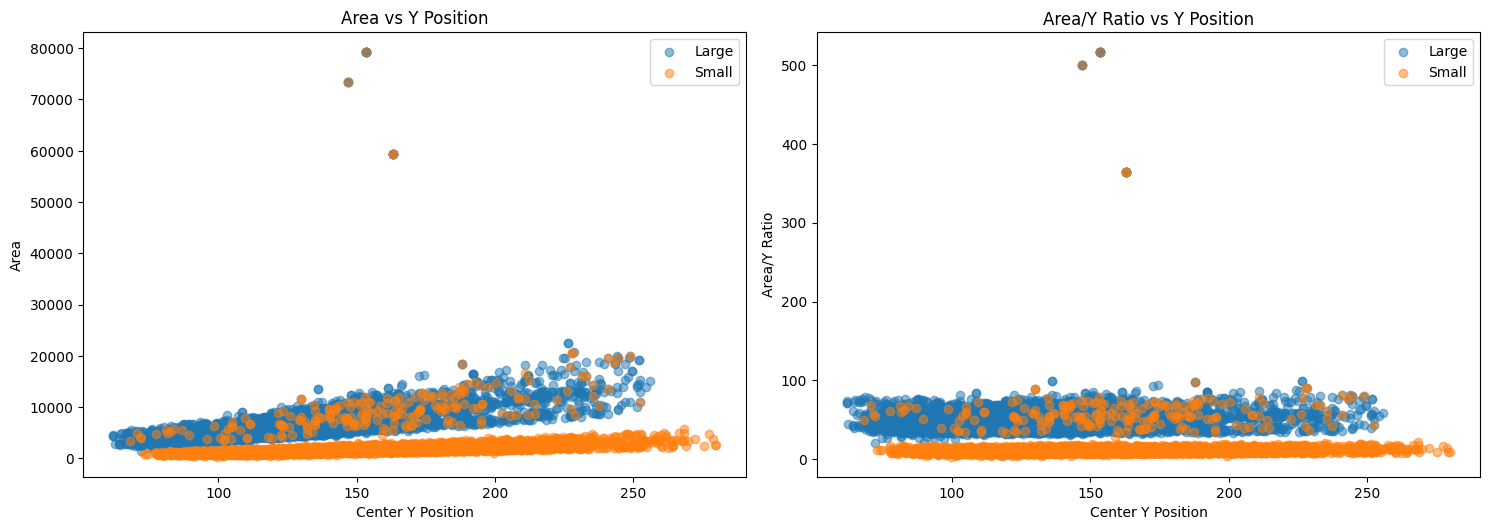

20.06382978723404 0.9670584596350139


In [7]:
import matplotlib.pyplot as plt
def add_features(df):
    # 直接从数组中获取 x, y, w, h
    df['x'] = df['csv_box'].apply(lambda x: x[0])
    df['y'] = df['csv_box'].apply(lambda x: x[1])
    df['width'] = df['csv_box'].apply(lambda x: x[2])
    df['height'] = df['csv_box'].apply(lambda x: x[3])

    # 计算box的中心y坐标（用于表示物体的远近）
    df['center_y'] = df['y'] + df['height']/2

    # 计算纵横比
    df['aspect_ratio'] = df['width'] / df['height']

    # 创建复合特征：面积与y位置的关系
    df['area_y_ratio'] = df['csv_area'] / df['center_y']

    return df

def analyze_size_distribution(df):
    plt.figure(figsize=(15, 10))

    # 散点图：面积 vs y位置
    plt.subplot(2, 2, 1)
    plt.scatter(df[df['json_size'] == 'large']['center_y'],
                df[df['json_size'] == 'large']['csv_area'],
                label='Large', alpha=0.5)
    plt.scatter(df[df['json_size'] == 'small']['center_y'],
                df[df['json_size'] == 'small']['csv_area'],
                label='Small', alpha=0.5)
    plt.xlabel('Center Y Position')
    plt.ylabel('Area')
    plt.legend()
    plt.title('Area vs Y Position')

    # 散点图：area_y_ratio的分布
    plt.subplot(2, 2, 2)
    plt.scatter(df[df['json_size'] == 'large']['center_y'],
                df[df['json_size'] == 'large']['area_y_ratio'],
                label='Large', alpha=0.5)
    plt.scatter(df[df['json_size'] == 'small']['center_y'],
                df[df['json_size'] == 'small']['area_y_ratio'],
                label='Small', alpha=0.5)
    plt.xlabel('Center Y Position')
    plt.ylabel('Area/Y Ratio')
    plt.legend()
    plt.title('Area/Y Ratio vs Y Position')

    plt.tight_layout()
    plt.show()

def find_best_threshold(df):
    ratios = sorted(df['area_y_ratio'].unique())
    best_accuracy = 0
    best_threshold = 0

    for threshold in ratios:
        predictions = (df['area_y_ratio'] > threshold).map({True: 'large', False: 'small'})
        accuracy = (predictions == df['json_size']).mean()

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold

    return best_threshold, best_accuracy

# 执行分析
df_size = add_features(df_size)
analyze_size_distribution(df_size)
threshold, accuracy = find_best_threshold(df_size)
print(threshold, accuracy)